<a href="https://colab.research.google.com/github/Parv-01/Kshitij_Sir_Repo_Check_IITP/blob/main/Po_Em_MHLCDS_executability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Po-Em-MHLCDS: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/Po-Em-MHLCDS](https://github.com/Mishrakshitij/Po-Em-MHLCDS)  
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'Po-Em-MHLCDS'
COMMIT = 'e818447ca6dd541c075c160625b9b094777b0a72'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: e818447ca6dd541c075c160625b9b094777b0a72
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


### Compatibility with the repository requirements
The table checks installed versions against the base dependencies and optional dependency groups used by this experiment.

In [ ]:
import tomllib
from packaging.requirements import Requirement
from packaging.version import Version
import pandas as pd
from IPython.display import display
project_metadata = tomllib.loads((REPO_ROOT / 'pyproject.toml').read_text())['project']
assert Version(sys.version.split()[0]) in __import__('packaging.specifiers', fromlist=['SpecifierSet']).SpecifierSet(project_metadata['requires-python'])
extras = {
    'PACD': ['baselines', 'plots'], 'PADS': ['train', 'politeness', 'plots'],
    'RL-Emo-Per': ['train', 'figures'], 'PEPDS': ['train', 'plots'],
    'GenPADS': ['train', 'metrics', 'figures'], 'Po-Em-MHLCDS': ['plots'],
    'PAL': ['train', 'eval', 'plots'], 'e-THERAPIST': [],
    'Re-Po-PDS': ['train', 'plots'], 'ABLE': ['train', 'plots'], 'EDiSS': ['train', 'plots']
}[PROJECT]
specs = list(project_metadata.get('dependencies', []))
for extra in extras:
    specs += project_metadata.get('optional-dependencies', {}).get(extra, [])
dependency_rows = []
for spec in specs:
    requirement = Requirement(spec)
    if requirement.marker and not requirement.marker.evaluate():
        continue
    installed = metadata.version(requirement.name)
    compatible = Version(installed) in requirement.specifier
    dependency_rows.append({'requirement': spec, 'installed': installed, 'compatible': compatible})
assert dependency_rows and all(row['compatible'] for row in dependency_rows)
display(pd.DataFrame(dependency_rows))
(OUTPUT_DIR / 'environment_check.json').write_text(__import__('json').dumps({'python': sys.version.split()[0], 'checked_extras': extras, 'dependencies': dependency_rows}, indent=2))
print('PASS: Python and all dependencies declared for the tested paths are compatible.')


,requirement,installed,compatible
0,"torch>=2.2,<3",2.13.0+cu129,True
1,"transformers>=4.45,<6",4.57.6,True
2,numpy>=1.24,2.3.5,True
3,matplotlib>=3.7,3.10.7,True


PASS: Python and all dependencies declared for the tested paths are compatible.


## Data integrity and exploratory analysis
This check uses the released MHLCD corpus and its dialogue-level partitions. The
five-update budget covers three reward classifiers, one counselor MLE update,
and one counselor PPO update. All models start from downloaded tiny checkpoints.
The tiny classifiers have randomly initialized task heads; their scores only
demonstrate the reward/evaluation code paths.

,utterances,dialogues
split,,
test,4163,151
train,20886,755
validation,2795,100


,authorRole,utterances,politeness,counselling-strategy,empathy,split
0,counselor,Rakshak welcomes you in a safe and secured env...,2.0,1.0,0.0,train
1,victim,Hi rakshak! I need your help.,NaN,NaN,NaN,train
2,counselor,Rakshak is committed to assisting you in this ...,2.0,1.0,0.0,train
3,victim,I am <person_name> and I am <person_age> years...,NaN,NaN,NaN,train


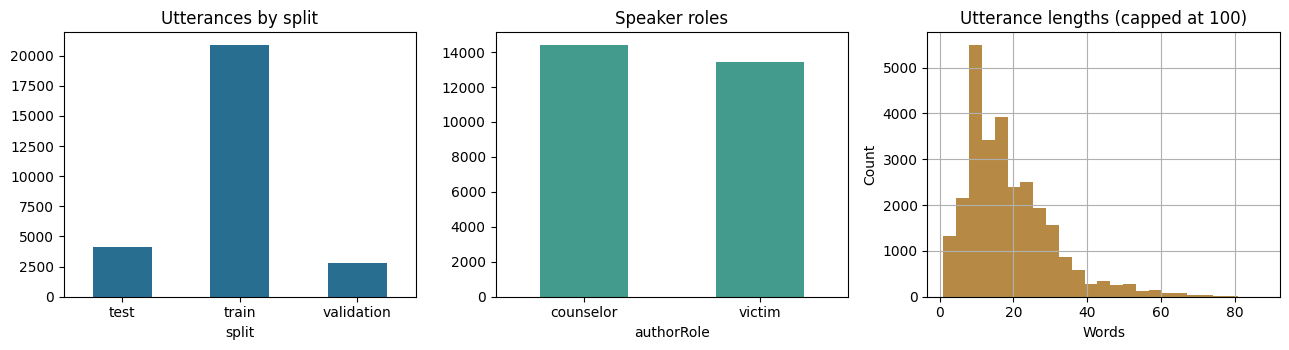

Integrity checks passed; four counselor examples per split are selected by native data loaders.


In [ ]:
import sys, json, math, subprocess, hashlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.optim.optimizer import register_optimizer_step_post_hook
from IPython.display import display
sys.path.insert(0, str(REPO_ROOT / 'src'))
from poem.cli import parser, validate, evaluate
from poem.training import train_classifier, train_mle, train_rl, load_lm
from poem.data import load_dialogues, examples
torch.set_num_threads(2)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
data_dir = REPO_ROOT / 'datasets'
df = pd.read_csv(data_dir / 'MHLCD.csv')
splits = pd.read_csv(data_dir / 'splits.csv')
assert not splits.dialogueId.duplicated().any()
df = df.merge(splits, on='dialogueId', validate='many_to_one')
assert len(df) == 27844 and df.dialogueId.nunique() == 1006
counts = df.groupby('split').agg(utterances=('utterances','size'), dialogues=('dialogueId','nunique'))
display(counts)
display(df[['authorRole','utterances','politeness','counselling-strategy','empathy','split']].head(4))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
counts['utterances'].plot.bar(ax=axes[0], color='#276e90', rot=0, title='Utterances by split')
df.authorRole.value_counts().plot.bar(ax=axes[1], color='#429b8c', rot=0, title='Speaker roles')
df.utterances.fillna('').str.split().str.len().clip(upper=100).hist(ax=axes[2], bins=25, color='#b68a45')
axes[2].set(title='Utterance lengths (capped at 100)', xlabel='Words', ylabel='Count')
fig.tight_layout(); fig.savefig(OUTPUT_DIR / 'dataset_overview.png', dpi=140); plt.show()
split_ids = {s: set(splits.loc[splits.split == s, 'dialogueId']) for s in ['train','validation','test']}
assert all(not split_ids[a] & split_ids[b] for a,b in [('train','validation'),('train','test'),('validation','test')])
selected = {s: list(examples(load_dialogues(data_dir, s), 'counselor'))[:4] for s in split_ids}
pd.DataFrame([{'split': s, 'dialogue_id': x['row']['dialogueId'], 'response': x['response']}
              for s, rows in selected.items() for x in rows]).to_csv(OUTPUT_DIR / 'selected_samples.csv', index=False)
print('Integrity checks passed; four counselor examples per split are selected by native data loaders.')

## Load and train the native reward classifiers
One batch of four real training examples is used for each of strategy,
politeness, and empathy. The repository saves each classifier and tokenizer.

In [ ]:
updates = []
handle = register_optimizer_step_post_hook(lambda optimizer,args,kwargs: updates.append(type(optimizer).__name__))
def native_args(command, model, output, limit=4, **options):
    argv = [command, '--model', str(model), '--output', str(output), '--device', DEVICE,
            '--dataset-dir', str(data_dir), '--max-length', '64', '--limit', str(limit), '--batch-size', '4']
    if command.startswith('train'):
        argv += ['--epochs', '1', '--learning-rate', '0.0001']
    for key,value in options.items():
        argv += ['--' + key.replace('_','-'), str(value)]
    args = parser().parse_args(argv); validate(args); return args
for task in ['strategy', 'politeness', 'empathy']:
    train_classifier(native_args('train-classifier', ENCODER_MODEL, OUTPUT_DIR/task, task=task))
assert len(updates) == 3
print('Three optimizer updates completed; three reward checkpoints saved.')

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at hf-internal-testing/tiny-random-roberta and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 32]) in the checkpoint and torch.Size([11, 32]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([11]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{"epoch": 1, "task": "strategy", "train_loss": 2.395233154296875, "validation": {"accuracy": 0.5, "macro_f1": 0.0606060606060606, "per_class_f1": [0.0, 0.6666666666666666, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "confusion_matrix": [[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], "examples": 4}}


python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at hf-internal-testing/tiny-random-roberta and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 32]) in the checkpoint and torch.Size([3, 32]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{"epoch": 1, "task": "politeness", "train_loss": 1.0872786045074463, "validation": {"accuracy": 0.0, "macro_f1": 0.0, "per_class_f1": [0.0, 0.0, 0.0], "confusion_matrix": [[0, 0, 0], [0, 0, 0], [0, 4, 0]], "examples": 4}}


{"epoch": 1, "task": "empathy", "train_loss": 0.6954061985015869, "validation": {"accuracy": 0.75, "macro_f1": 0.42857142857142855, "per_class_f1": [0.8571428571428571, 0.0], "confusion_matrix": [[3, 0], [1, 0]], "examples": 4}}


Three optimizer updates completed; three reward checkpoints saved.


## Counselor MLE and PPO training
One native MLE update is followed by one PPO update with three sampled
candidates, one PPO epoch and the repository's five reward components. This
brings the complete project run to five optimizer updates.

In [ ]:
train_mle(native_args('train-mle', CAUSAL_MODEL, OUTPUT_DIR/'mle', role='counselor', max_response=16))
before, _ = load_lm(str(OUTPUT_DIR/'mle/counselor'), 'cpu')
before_state = {k: v.detach().clone() for k,v in before.state_dict().items()}
del before
reward_options = {task+'_checkpoint': OUTPUT_DIR/task for task in ['strategy','politeness','empathy']}
train_rl(native_args('train-rl', OUTPUT_DIR/'mle/counselor', OUTPUT_DIR/'ppo', limit=1,
                    max_new_tokens=8, num_candidates=3, ppo_epochs=1, log_every=1,
                    encoder=ENCODER_MODEL, **reward_options))
handle.remove()
assert len(updates) == 5
reloaded, tokenizer = load_lm(str(OUTPUT_DIR/'ppo'), DEVICE)
changed = sum(not torch.equal(before_state[k], v.detach().cpu()) for k,v in reloaded.state_dict().items())
assert changed > 0
assert (OUTPUT_DIR/'ppo/optimizer.pt').is_file()
print({'actual_optimizer_updates': len(updates), 'PPO_changed_tensors': changed, 'checkpoint_reload': 'PASS'})
del reloaded

{"epoch": 1, "role": "counselor", "train_loss": 10.827875137329102, "validation": {"nll": 10.827611923217773, "perplexity": 50393.22010164194, "tokens": 64}}


Some weights of RobertaModel were not initialized from the model checkpoint at hf-internal-testing/tiny-random-roberta and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{"step": 1, "epoch": 1, "reward": -0.5179059505462646, "components": [-1.7205009460449219, -0.9923352003097534, -0.4996205270290375, 0.9831773638725281, 1.0], "loss": -3.3080577850341797e-06, "approx_kl": 0.0, "clip_fraction": 0.0}


{"epoch": 1, "validation": {"nll": 10.833024978637695, "perplexity": 50666.74101890906, "tokens": 8}}


{'actual_optimizer_updates': 5, 'PPO_changed_tensors': 29, 'checkpoint_reload': 'PASS'}


## Native held-out evaluation
Four counselor turns from the original test partition are evaluated after
loading the saved PPO checkpoint. Generated text and reference perplexity are
execution diagnostics. No counseling quality or paper-level result is inferred.

{"split": "test", "reference_lm": {"nll": 10.82773208618164, "perplexity": 50399.27586416007, "tokens": 32}, "responses": 4, "mean_response_words": 5.5, "distinct_1": 1.0, "distinct_2": 1.0, "strategy_reference_agreement": 0.5, "politeness_reference_agreement": 0.0, "Pol": 0.0, "empathy_reference_agreement": 0.75, "Emp": 0.0}


,dialogueId,utteranceNo,response
0,3241,0,Tagフ garlicventory fartherrade transforming dist
1,3241,2,BeforecookedPerson Collider witnessesğ proport...
2,3241,4,fendGW ownerighter asserting641 loves 199
3,3241,6,higherrought lacked Con dishon logs towns Pla...


,nll,perplexity,tokens
0,10.827732,50399.275864,32


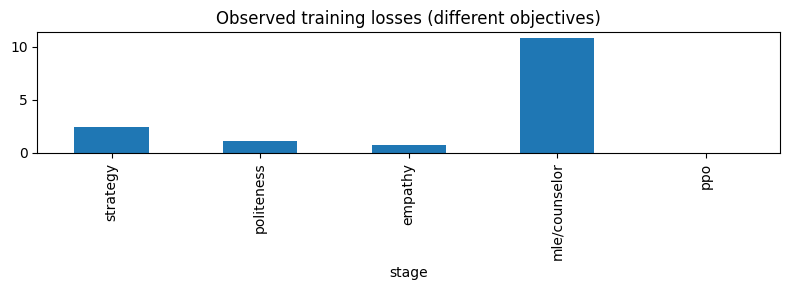

PASS: downloaded models, five native updates, checkpoint save/reload, and four held-out predictions verified.


In [ ]:
evaluate(native_args('evaluate', OUTPUT_DIR/'ppo', OUTPUT_DIR/'evaluation.json',
                     max_new_tokens=8, num_candidates=1, split='test', **reward_options))
metrics = json.loads((OUTPUT_DIR/'evaluation.json').read_text())
predictions = pd.read_json(OUTPUT_DIR/'evaluation.responses.jsonl', lines=True)
assert len(predictions) == 4
assert math.isfinite(metrics['reference_lm']['nll'])
display(predictions)
display(pd.DataFrame([metrics['reference_lm']]))
logs = []
for stage in ['strategy','politeness','empathy','mle/counselor','ppo']:
    for line in (OUTPUT_DIR/stage/'metrics.jsonl').read_text().splitlines():
        record = json.loads(line)
        if 'train_loss' in record: logs.append({'stage': stage, 'loss': record['train_loss']})
        elif 'loss' in record: logs.append({'stage': stage, 'loss': record['loss']})
loss_df = pd.DataFrame(logs)
ax = loss_df.plot.bar(x='stage', y='loss', legend=False, figsize=(8,3), title='Observed training losses (different objectives)')
ax.figure.tight_layout(); ax.figure.savefig(OUTPUT_DIR/'training_losses.png', dpi=140); plt.show()
result = {
    'project': 'Po-Em-MHLCDS', 'status': 'PASS', 'optimizer_updates': len(updates),
    'eval_samples': 4, 'train_samples': 4, 'dataset_rows': len(df), 'dialogues': int(df.dialogueId.nunique()),
    'model': CAUSAL_MODEL, 'encoder_model': ENCODER_MODEL,
    'commit': subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip(),
    'metrics': metrics, 'changed_tensors': changed, 'checkpoint_reload': True,
    'native_paths': ['poem.training.train_classifier','poem.training.train_mle','poem.training.train_rl','poem.cli.evaluate'],
    'checkpoints': ['strategy','politeness','empathy','mle/counselor','ppo'],
    'limitations': ['Tiny randomly initialized encoder and task heads validate execution only.',
        'The victim model and binary counseling classifier are not trained within the five-update budget.',
        'Four test turns are insufficient for a performance claim; full-size paper experiments are not reproduced.']}
(OUTPUT_DIR/'result.json').write_text(json.dumps(result, indent=2, allow_nan=False))
print('PASS: downloaded models, five native updates, checkpoint save/reload, and four held-out predictions verified.')

## Project summary

**Result: PASS for the tested smoke configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved and reloaded, and the evaluation covered **4 held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.